In [1]:
#install.packages("SoupX")

In [2]:
library(Seurat)
library(SoupX)
library(DropletUtils)
library(ggplot2)
library(knitr)

Warning message:
“package ‘Seurat’ was built under R version 4.0.5”
Attaching SeuratObject

Attaching sp

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, ro

In [3]:

path2mtx = function(barcode = 'barcodes.tsv.gz',
                    feature = 'features.tsv.gz',
                    matrix = 'matrix.mtx.gz',
                    samp.path){
    mtxfile = paste0(samp.path,  matrix)
    barcodes_file = paste0(samp.path, barcode)
    feature_file = paste0(samp.path, feature)
    
    mtx = ReadMtx(
        mtx = mtxfile,
        features = feature_file,
        cells = barcodes_file
      )
    
    return(mtx)
  
}



In [4]:
StartSolo2SoupX = function(samp.path, feature = 'features.tsv.gz', soupX.path){
    filt.matrix = path2mtx(samp.path = paste0(samp.path, "output/Gene/filtered/"), feature = feature)
    raw.matrix = path2mtx(samp.path = paste0(samp.path, "output/Gene/raw/"), feature = feature)
    srat = CreateSeuratObject(counts = filt.matrix)
    soup.channel = SoupChannel(raw.matrix, filt.matrix)
    #cluster with Seurat
    srat = SCTransform(srat, verbose = F)
    srat = RunPCA(srat, verbose = F)
    srat = RunUMAP(srat, dims = 1:30, verbose = F)
    srat = FindNeighbors(srat, dims = 1:30, verbose = F)
    srat = FindClusters(srat, verbose = T)
    
    meta = srat@meta.data
    umap = srat@reductions$umap@cell.embeddings
    print("SoupX ...")
    soup.channel = setClusters(soup.channel, setNames(meta$seurat_clusters, rownames(meta)))
    soup.channel = setDR(soup.channel, umap)
    soup.channel = autoEstCont(soup.channel)
    head(soup.channel$soupProfile[order(soup.channel$soupProfile$est, decreasing = T), ], n = 10)
    adj.matrix = adjustCounts(soup.channel, roundToInt = T)
    DropletUtils:::write10xCounts(soupX.path, adj.matrix, version = "3")
    
}

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 13654
Number of edges: 484155

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8997
Number of communities: 22
Elapsed time: 1 seconds
[1] "SoupX ..."


862 genes passed tf-idf cut-off and 307 soup quantile filter.  Taking the top 100.

Using 1232 independent estimates of rho.

Estimated global rho of 0.02

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 22 clusters to 13654 cells.



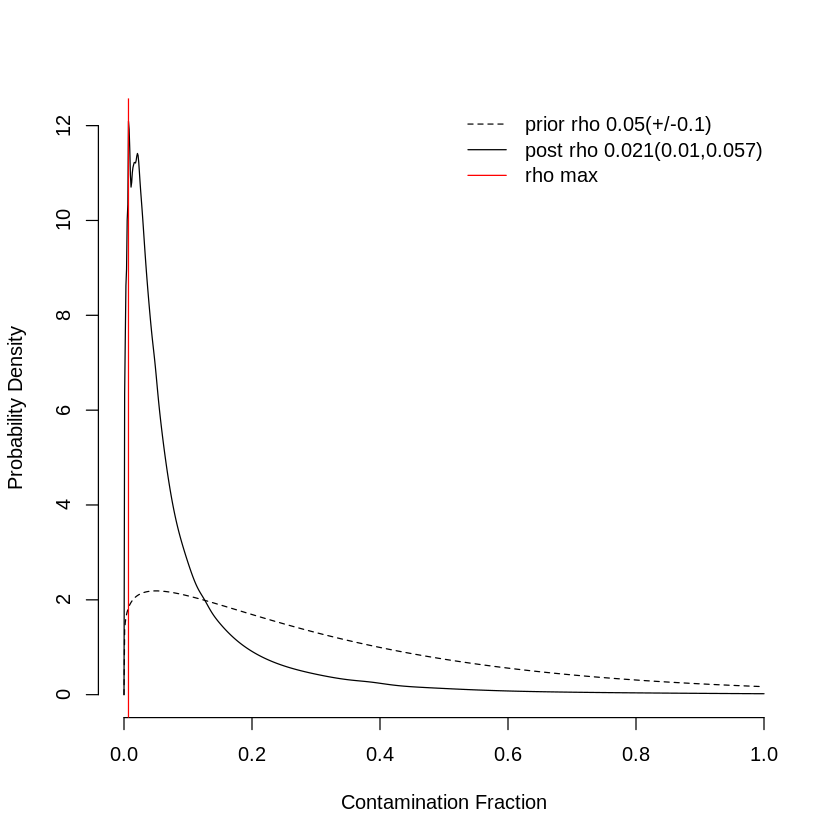

In [5]:
StartSolo2SoupX(samp.path="/lustre/scratch117/cellgen/cellgeni/TIC-starsolo/tic-1808/GSE121380/GSM3433578/", feature = 'genes.tsv.gz', soupX.path="/lustre/scratch126/cellgen/team205/bh14/starsolo_SoupX/Essai_filt_2")

##### E-MTAB-8322_Stefeno_2020

[1] "1: Processing ERS3741151"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1040
Number of edges: 41698

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7429
Number of communities: 7
Elapsed time: 0 seconds
[1] "SoupX ..."


31 genes passed tf-idf cut-off and 24 soup quantile filter.  Taking the top 24.

Using 95 independent estimates of rho.

Estimated global rho of 0.01

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 7 clusters to 1040 cells.



[1] "2: Processing ERS3741152"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2056
Number of edges: 78015

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7767
Number of communities: 9
Elapsed time: 0 seconds
[1] "SoupX ..."


209 genes passed tf-idf cut-off and 72 soup quantile filter.  Taking the top 72.

Using 478 independent estimates of rho.

Estimated global rho of 0.02

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 9 clusters to 2056 cells.



[1] "3: Processing ERS3741153"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2358
Number of edges: 94782

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7247
Number of communities: 9
Elapsed time: 0 seconds
[1] "SoupX ..."


24 genes passed tf-idf cut-off and 19 soup quantile filter.  Taking the top 19.

Using 60 independent estimates of rho.

Estimated global rho of 0.01



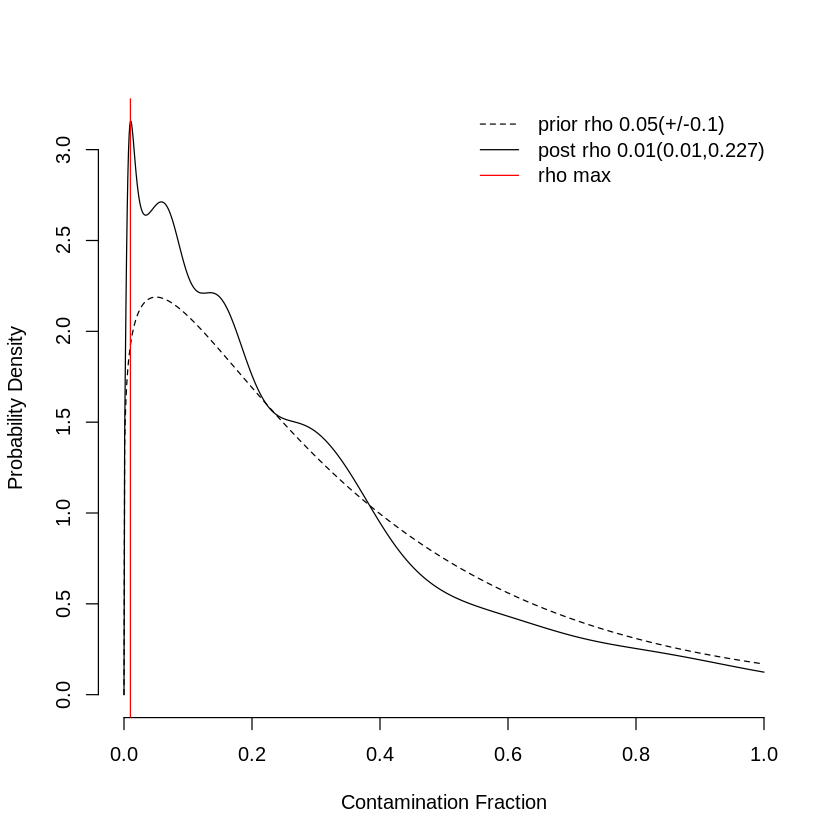

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 9 clusters to 2358 cells.



[1] "4: Processing ERS3741154"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 970
Number of edges: 37538

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7353
Number of communities: 7
Elapsed time: 0 seconds
[1] "SoupX ..."


44 genes passed tf-idf cut-off and 31 soup quantile filter.  Taking the top 31.

Using 123 independent estimates of rho.

Estimated global rho of 0.01



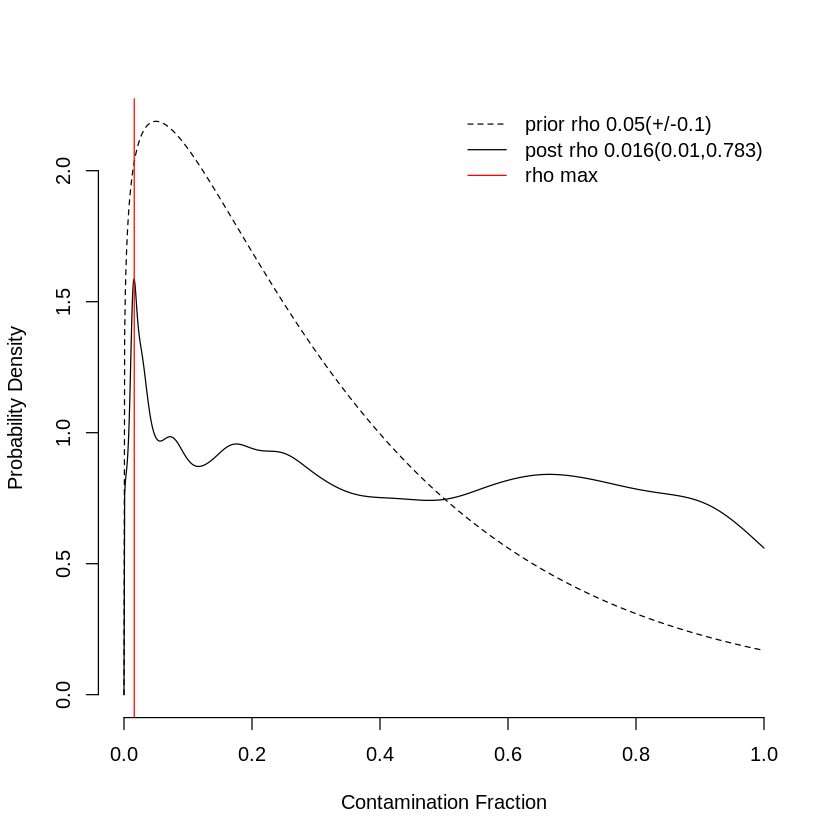

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 7 clusters to 970 cells.



[1] "5: Processing ERS3741155"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1756
Number of edges: 71385

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7841
Number of communities: 10
Elapsed time: 0 seconds
[1] "SoupX ..."


33 genes passed tf-idf cut-off and 28 soup quantile filter.  Taking the top 28.

Using 172 independent estimates of rho.

Estimated global rho of 0.02



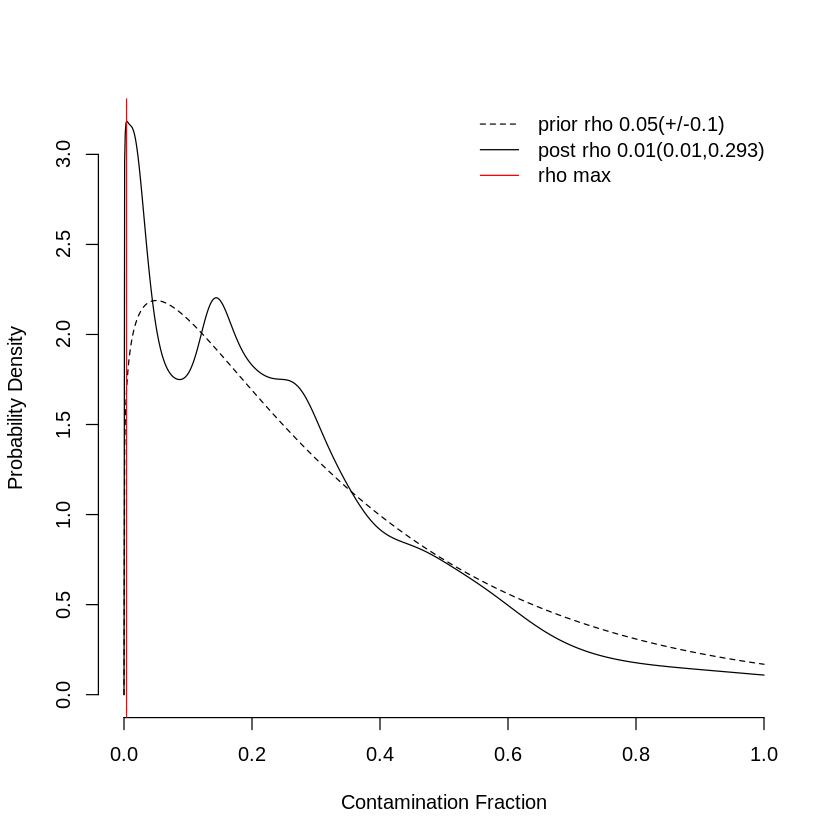

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 10 clusters to 1756 cells.



[1] "6: Processing ERS3741156"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2089
Number of edges: 78127

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8019
Number of communities: 9
Elapsed time: 0 seconds
[1] "SoupX ..."


115 genes passed tf-idf cut-off and 36 soup quantile filter.  Taking the top 36.

Using 159 independent estimates of rho.

Estimated global rho of 0.03



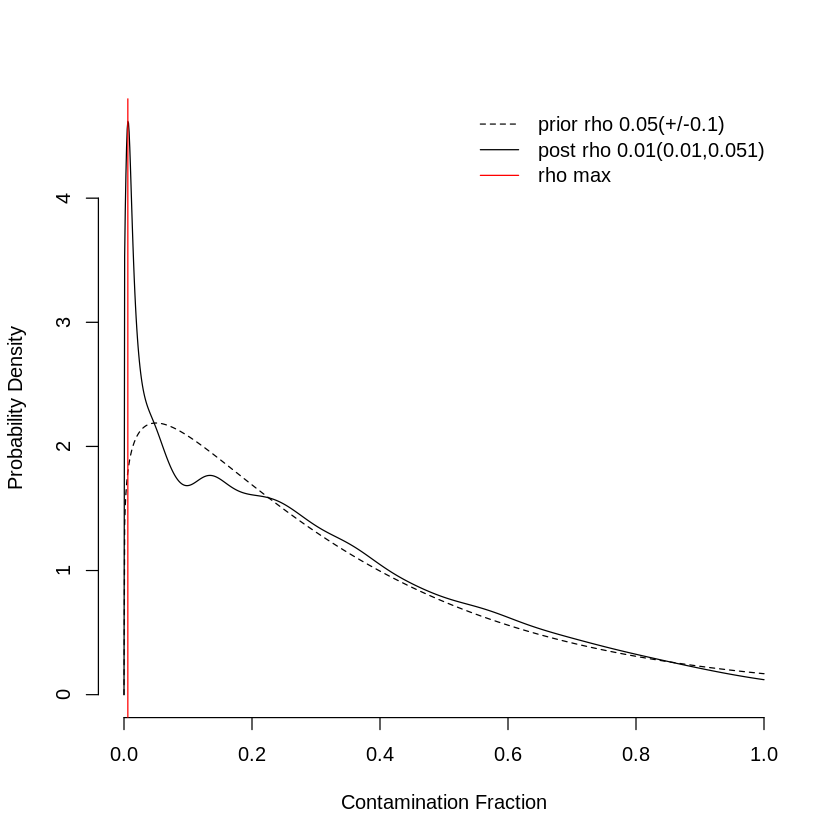

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 9 clusters to 2089 cells.



[1] "7: Processing ERS3741157"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 687
Number of edges: 26091

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7718
Number of communities: 7
Elapsed time: 0 seconds
[1] "SoupX ..."


40 genes passed tf-idf cut-off and 29 soup quantile filter.  Taking the top 29.

Using 114 independent estimates of rho.

Estimated global rho of 0.03



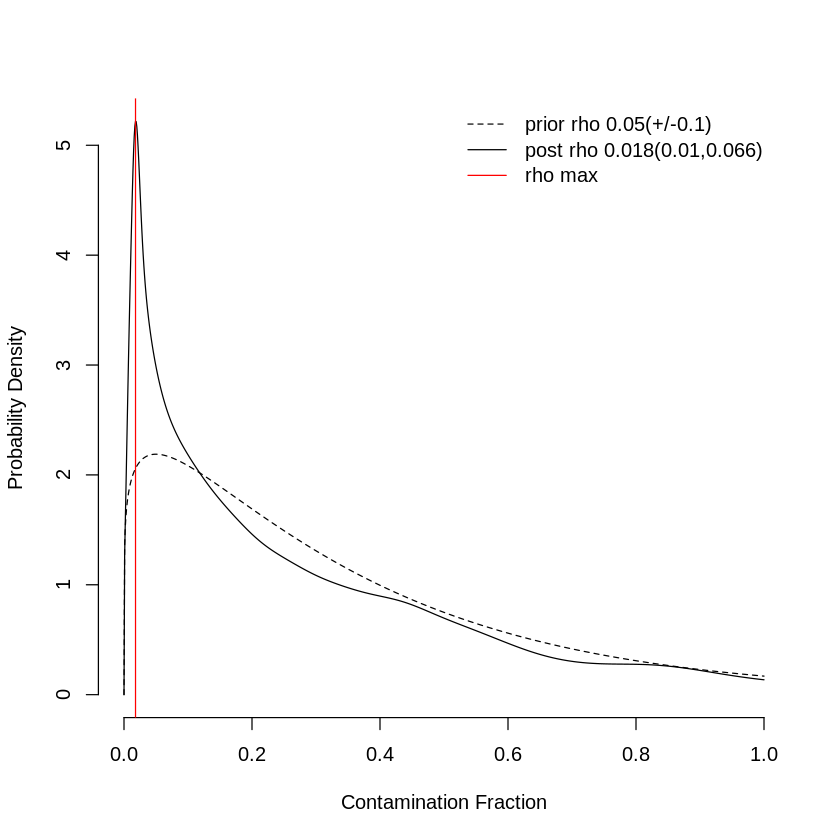

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 7 clusters to 687 cells.



[1] "8: Processing ERS3741158"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2531
Number of edges: 86503

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8217
Number of communities: 12
Elapsed time: 0 seconds
[1] "SoupX ..."


396 genes passed tf-idf cut-off and 230 soup quantile filter.  Taking the top 100.

Using 809 independent estimates of rho.

Estimated global rho of 0.02



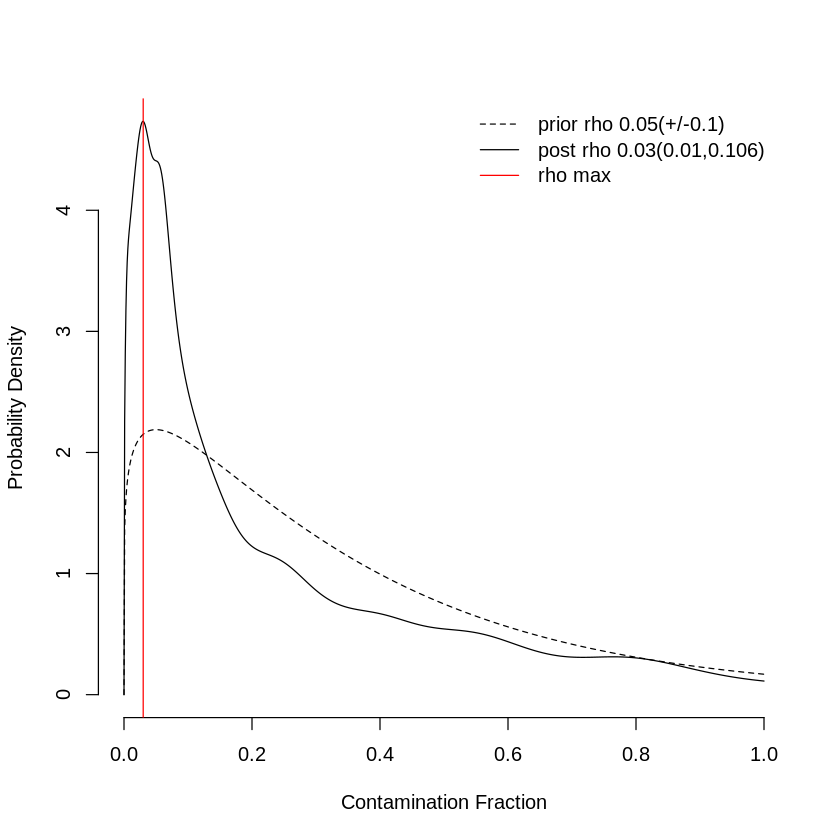

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 12 clusters to 2531 cells.



[1] "9: Processing ERS3741159"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11695
Number of edges: 415899

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8670
Number of communities: 21
Elapsed time: 1 seconds
[1] "SoupX ..."


391 genes passed tf-idf cut-off and 284 soup quantile filter.  Taking the top 100.

Using 1276 independent estimates of rho.

Estimated global rho of 0.05



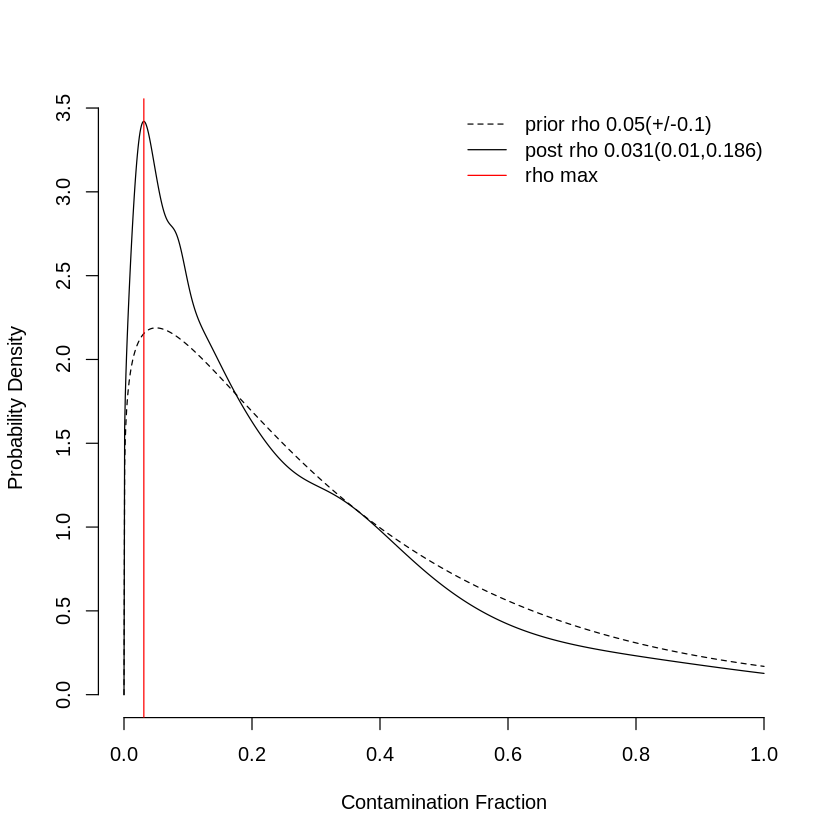

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 21 clusters to 11695 cells.



[1] "10: Processing ERS3741160"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2119
Number of edges: 66686

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8757
Number of communities: 13
Elapsed time: 0 seconds
[1] "SoupX ..."


866 genes passed tf-idf cut-off and 355 soup quantile filter.  Taking the top 100.

Using 821 independent estimates of rho.

Estimated global rho of 0.01



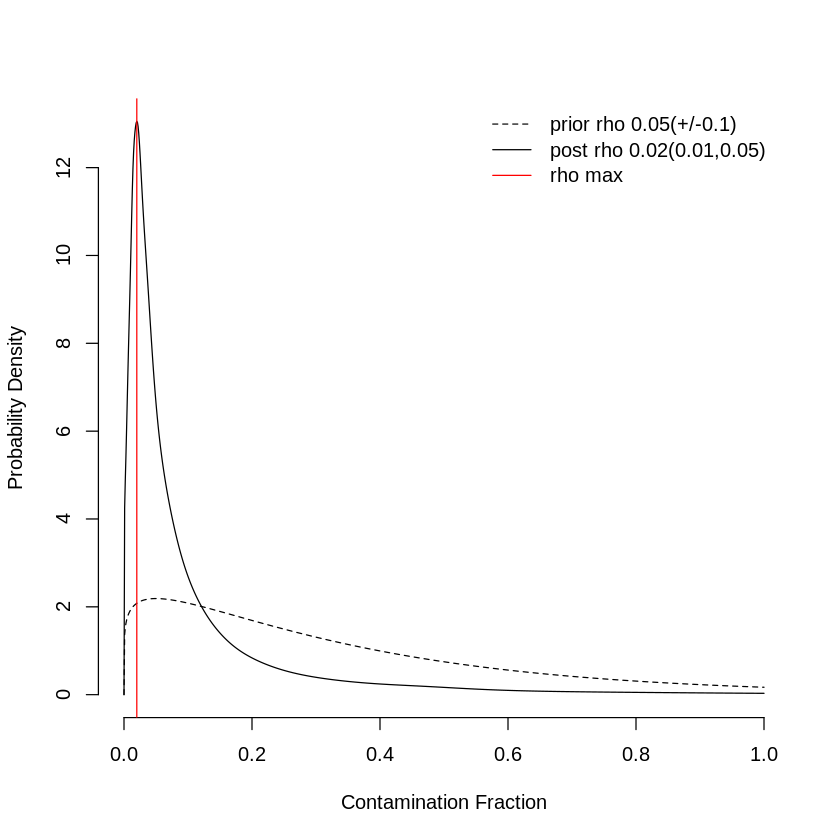

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 13 clusters to 2119 cells.



[1] "11: Processing ERS3741161"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 773
Number of edges: 37229

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6728
Number of communities: 7
Elapsed time: 0 seconds
[1] "SoupX ..."


116 genes passed tf-idf cut-off and 92 soup quantile filter.  Taking the top 92.

Using 414 independent estimates of rho.

Estimated global rho of 0.01



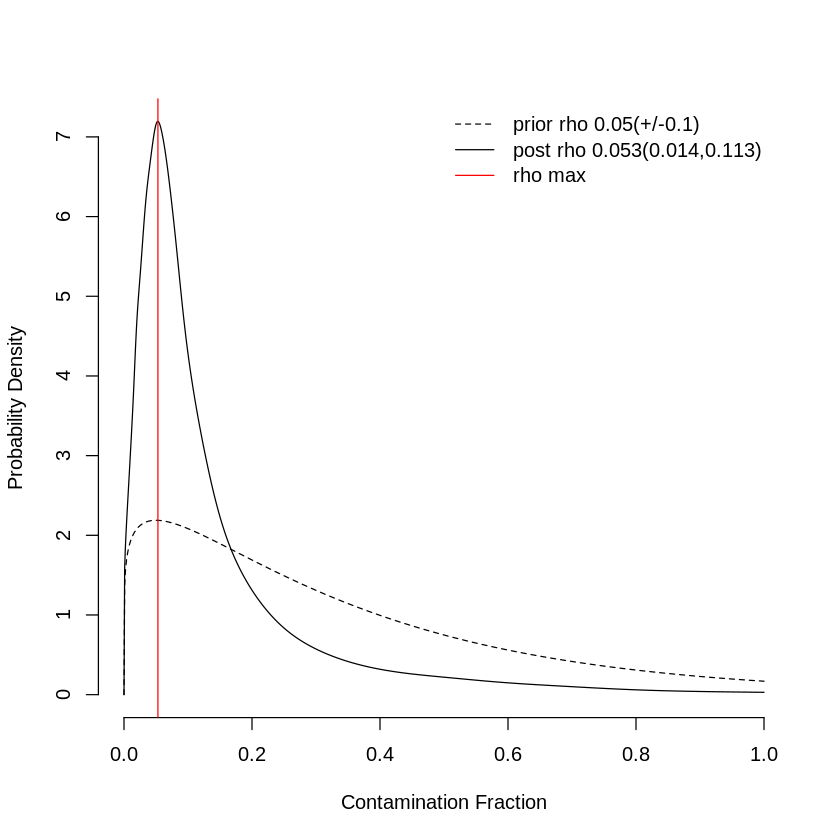

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 7 clusters to 773 cells.



[1] "12: Processing ERS3741162"
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1182
Number of edges: 44246

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7740
Number of communities: 8
Elapsed time: 0 seconds
[1] "SoupX ..."


45 genes passed tf-idf cut-off and 38 soup quantile filter.  Taking the top 38.

Using 158 independent estimates of rho.

Estimated global rho of 0.02



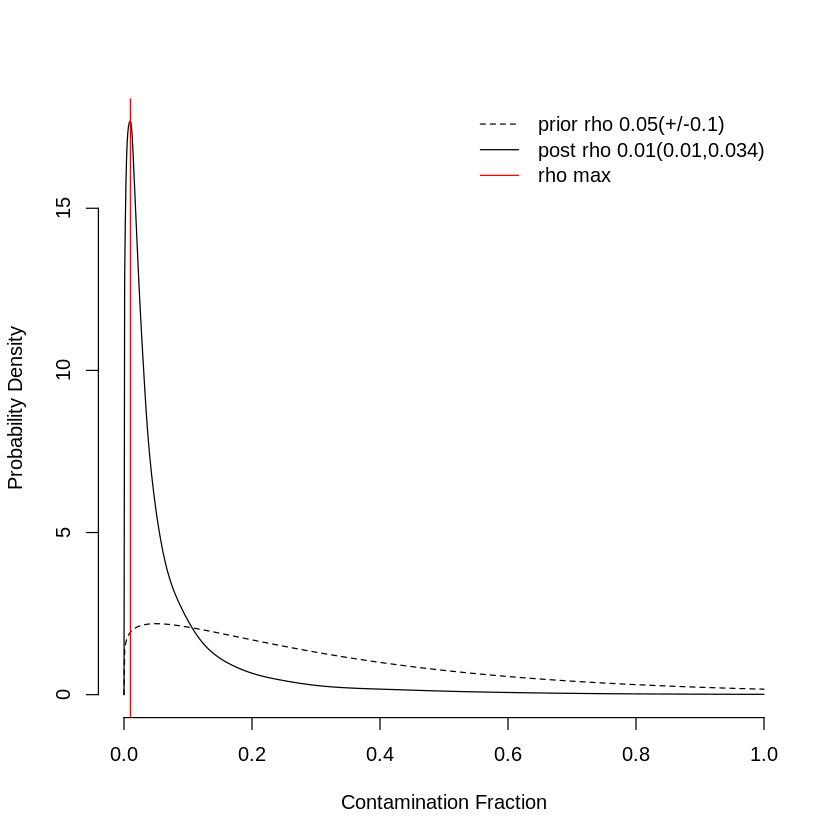

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' has been deprecated; setting 'repr = "T"' for you”
Expanding counts from 8 clusters to 1182 cells.



In [ ]:
path="/lustre/scratch117/cellgen/cellgeni/TIC-starsolo/tic-1808/E-MTAB-8322/"

files = list.files("/lustre/scratch117/cellgen/cellgeni/TIC-starsolo/tic-1808/E-MTAB-8322/", pattern = "ERS*")

for(i in 1:length(files)){
    file = files[i]
    print(paste0(i, ": Processing ", file))
    s_p = paste0("/lustre/scratch126/cellgen/team205/bh14/starsolo_SoupX/", file)
    StartSolo2SoupX(samp.path=paste0(path, file, "/"), soupX.path=s_p)
    
}


In [ ]:
length(list.files("/lustre/scratch117/cellgen/cellgeni/TIC-starsolo/tic-1808/E-MTAB-8322/", pattern = "ERS*"))
